# Objetivo 2 — Predicción de Mortalidad Hospitalaria en UCI
**Dataset:** Cohorte APACHE II — MIMIC-IV | N = 20,884 | Mortalidad: 15.5%

**Pipeline:**
1. Carga y división estratificada (60/20/20)
2. Preprocesamiento sin data leakage
3. Balanceo de clases (4 estrategias)
4. Entrenamiento: LR · RF · SVM · GB · MLP · XGBoost nativo
5. Evaluación con umbral óptimo (validación) + IC95% bootstrap
6. Comparación vs SOFA y APACHE II
7. Interpretabilidad: SHAP + LIME (4 casos clínicos)

**SEED = 42 | Umbral óptimo siempre buscado en validación, evaluado en test**


## 1 — Instalación y librerías

In [35]:
# Descomenta en Colab:
# !pip install scikit-learn xgboost shap lime pandas numpy matplotlib imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline   
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, time, os, io, random
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.neighbors        import NearestNeighbors
from sklearn.base             import clone
from sklearn.calibration      import calibration_curve
from sklearn.metrics          import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, f1_score,
    recall_score, precision_score, brier_score_loss
)
import xgboost as xgb

SEED = 42
np.random.seed(SEED)
print(f'sklearn OK | xgboost {xgb.__version__} | numpy {np.__version__}')


sklearn OK | xgboost 3.2.0 | numpy 2.3.2


## 2 — Carga de datos y variables

In [36]:
# ── Ajusta la ruta según tu entorno ──────────────────────────────────────────
DATA_PATH = 'A:\\GitHubTesis\\CohorteFinalTesis.csv'   # Colab: sube el archivo o usa Drive

df = pd.read_csv(DATA_PATH)

print(f'Pacientes totales : {len(df):,}')
print(f'Fallecidos        : {df["mortality_hosp"].sum():,}  ({df["mortality_hosp"].mean()*100:.1f}%)')
print(f'Supervivientes    : {(df["mortality_hosp"]==0).sum():,}')

NUM_FEATURES = [
    'anchor_age', 'charlson',
    'aniongap_max', 'bicarbonate_min', 'lactate_max', 'ph_min', 'glucose_max',
    'uo_24hr', 'bun_max', 'creatinine_max', 'sbp_min', 'meanbp_min',
    'inr_max', 'bilirubin_max', 'platelet_min', 'pf_worst',
    'heart_rate_max', 'resp_rate_max', 'temperature_min',
    'gcs_min', 'wbc_max', 'ventilation_24h', 'vasopressor_24h',
]
CAT_FEATURES = ['gender']
SCORES_REF   = ['sofa_24h', 'apache_ii_totall']
TARGET       = 'mortality_hosp'

for col in NUM_FEATURES + CAT_FEATURES + [TARGET]:
    if col not in df.columns:
        print(f'  FALTA columna: {col}')

X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET]
print(f'\nFeatures: {len(NUM_FEATURES)} numéricas + {len(CAT_FEATURES)} categóricas')


Pacientes totales : 20,884
Fallecidos        : 3,241  (15.5%)
Supervivientes    : 17,643

Features: 23 numéricas + 1 categóricas


## 3 — División estratificada 60 / 20 / 20

In [37]:
# Split fijo (SEED=42) estratificado — mantiene 15.5% mortalidad en cada split
# REGLA: preprocesamiento ajustado SOLO en train (sin data leakage)
#        test set evaluado UNA SOLA VEZ al final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp)

for nombre, Xs, ys in [('Train', X_train, y_train),
                        ('Val  ', X_val,   y_val),
                        ('Test ', X_test,  y_test)]:
    print(f'  {nombre}: {len(Xs):>6,} pac.  |  mortalidad {ys.mean()*100:.1f}%')


  Train: 12,530 pac.  |  mortalidad 15.5%
  Val  :  4,177 pac.  |  mortalidad 15.5%
  Test :  4,177 pac.  |  mortalidad 15.5%


## 4 — Preprocesamiento (sin data leakage)

In [38]:
# Numéricas : mediana + StandardScaler  (fit SOLO en train)
# Categóricas: moda  + OneHotEncoder
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES)
])

preprocessor.fit(X_train)
X_train_t   = preprocessor.transform(X_train)
X_val_t     = preprocessor.transform(X_val)
X_test_t    = preprocessor.transform(X_test)
y_train_arr = y_train.values
y_val_arr   = y_val.values
y_test_arr  = y_test.values

n0 = (y_train_arr == 0).sum()
n1 = (y_train_arr == 1).sum()

try:
    cat_names     = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CAT_FEATURES)
    FEATURE_NAMES = NUM_FEATURES + list(cat_names)
except Exception:
    FEATURE_NAMES = [f'f{i}' for i in range(X_train_t.shape[1])]

print(f'Features tras OHE : {X_train_t.shape[1]}')
print(f'Ratio desbalance  : {n0/n1:.1f}:1  ({n1} fallecidos / {n0} supervivientes)')
print('Preprocesamiento ajustado SOLO en train ✓')


Features tras OHE : 25
Ratio desbalance  : 5.4:1  (1945 fallecidos / 10585 supervivientes)
Preprocesamiento ajustado SOLO en train ✓


## 5 — Balanceo de clases (4 estrategias)

In [39]:
# ── SMOTE (implementación propia, sin dependencia externa) ───────────────────
def smote_oversample(X_num, y, k_neighbors=5, random_state=42):
    rng     = np.random.RandomState(random_state)
    min_idx = np.where(y == 1)[0]
    maj_idx = np.where(y == 0)[0]
    X_min   = X_num[min_idx]
    n_syn   = len(maj_idx) - len(min_idx)
    if n_syn <= 0: return X_num, y
    nbrs = NearestNeighbors(n_neighbors=k_neighbors+1, n_jobs=-1).fit(X_min)
    _, indices = nbrs.kneighbors(X_min)
    synthetic = []
    for i in range(n_syn):
        idx      = i % len(min_idx)
        neighbor = rng.choice(indices[idx][1:])
        gap      = rng.random()
        synthetic.append(X_min[idx] + gap * (X_min[neighbor] - X_min[idx]))
    return (np.vstack([X_num, np.array(synthetic)]),
            np.concatenate([y, np.ones(len(synthetic), dtype=y.dtype)]))

X_smote, y_smote = smote_oversample(X_train_t, y_train_arr)

# ── Undersampling manual ──────────────────────────────────────────────────────
rng_   = np.random.RandomState(SEED)
n_min  = int(y_train_arr.sum())
maj_dw = rng_.choice(np.where(y_train_arr==0)[0], size=n_min, replace=False)
all_i  = np.concatenate([maj_dw, np.where(y_train_arr==1)[0]])
rng_.shuffle(all_i)
X_manual, y_manual = X_train_t[all_i], y_train_arr[all_i]

print(f'Original  : {len(y_train_arr):,}  ({y_train_arr.mean()*100:.1f}% fallecidos)')
print(f'SMOTE     : {len(y_smote):,}  ({y_smote.mean()*100:.1f}% fallecidos)')
print(f'Manual    : {len(y_manual):,}  ({y_manual.mean()*100:.1f}% fallecidos)')
print('class_weight y scale_pos_weight se configuran en cada modelo (ver Celda 6)')


Original  : 12,530  (15.5% fallecidos)
SMOTE     : 21,170  (50.0% fallecidos)
Manual    : 3,890  (50.0% fallecidos)
class_weight y scale_pos_weight se configuran en cada modelo (ver Celda 6)


## 6 — Funciones auxiliares y scores clínicos de referencia

In [40]:
def metricas(y_true, y_prob, umbral=0.5):
    yp = (y_prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp).ravel()
    return {
        'AUROC': round(roc_auc_score(y_true, y_prob), 4),
        'AUPRC': round(average_precision_score(y_true, y_prob), 4),
        'Sens':  round(recall_score(y_true, yp, zero_division=0), 4),
        'Spec':  round(tn/(tn+fp) if (tn+fp)>0 else 0, 4),
        'VPP':   round(precision_score(y_true, yp, zero_division=0), 4),
        'VPN':   round(tn/(tn+fn) if (tn+fn)>0 else 0, 4),
        'F1':    round(f1_score(y_true, yp, zero_division=0), 4),
        'Brier': round(brier_score_loss(y_true, y_prob), 4),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
    }

def best_threshold(y_true, y_prob):
    """Umbral óptimo F1 — siempre en validación, nunca en test."""
    bt, bf = 0.5, 0.0
    for t in np.arange(0.05, 0.96, 0.01):
        f = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f > bf:
            bf = f
            bt = t
    return round(bt, 3)

def bootstrap_ci(y_true, y_prob, umbral, n_boot=2000, seed=42):
    """IC95% bootstrap (N=2000) para AUROC, AUPRC y F1."""
    rng = np.random.RandomState(seed)
    boot = {'AUROC': [], 'AUPRC': [], 'F1': []}

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        yb, pb = y_true[idx], y_prob[idx]

        if len(np.unique(yb)) < 2:
            continue

        boot['AUROC'].append(roc_auc_score(yb, pb))
        boot['AUPRC'].append(average_precision_score(yb, pb))
        boot['F1'].append(f1_score(yb, (pb >= umbral).astype(int), zero_division=0))

    ci = {}
    for k, v in boot.items():
        v = sorted(v)
        n = len(v)
        ci[k] = (round(v[int(.025*n)], 4), round(v[int(.975*n)], 4))

    return ci

# ── Scores clínicos: umbral buscado en validación ────────────────────────────
ref_val  = df.loc[X_val.index,  SCORES_REF].copy()
ref_test = df.loc[X_test.index, SCORES_REF].copy()

def minmax_fit(s_fit, s_apply):
    mn, mx = s_fit.min(), s_fit.max()
    return ((s_apply - mn) / (mx - mn)).clip(0, 1) if mx > mn else s_apply * 0.0

for c in SCORES_REF:
    median_val = ref_val[c].median()
    ref_val[c]  = ref_val[c].fillna(median_val)
    ref_test[c] = ref_test[c].fillna(median_val)

s_sofa_val   = minmax_fit(ref_val['sofa_24h'], ref_val['sofa_24h'])
s_sofa       = minmax_fit(ref_val['sofa_24h'], ref_test['sofa_24h'])

s_apache_val = minmax_fit(ref_val['apache_ii_totall'], ref_val['apache_ii_totall'])
s_apache     = minmax_fit(ref_val['apache_ii_totall'], ref_test['apache_ii_totall'])

t_sofa   = best_threshold(y_val_arr, s_sofa_val.values)
t_apache = best_threshold(y_val_arr, s_apache_val.values)

m_sofa   = metricas(y_test_arr, s_sofa.values, umbral=t_sofa)
m_apache = metricas(y_test_arr, s_apache.values, umbral=t_apache)

ci_sofa   = bootstrap_ci(y_test_arr, s_sofa.values, t_sofa)
ci_apache = bootstrap_ci(y_test_arr, s_apache.values, t_apache)

print(f'SOFA   → AUROC={m_sofa["AUROC"]}  AUPRC={m_sofa["AUPRC"]}  F1={m_sofa["F1"]}  t={t_sofa}')
print(f'APACHE → AUROC={m_apache["AUROC"]}  AUPRC={m_apache["AUPRC"]}  F1={m_apache["F1"]}  t={t_apache}')

SOFA   → AUROC=0.7349  AUPRC=0.3899  F1=0.4219  t=0.32
APACHE → AUROC=0.7335  AUPRC=0.3274  F1=0.3904  t=0.37


## 7 — Definición de modelos y hiperparámetros

In [41]:
estrategias_ord = ['sin_balanceo', 'class_weight', 'smote', 'manual']
etiquetas = {
    'sin_balanceo': 'Sin balanceo',
    'class_weight': 'class_weight',
    'smote':        'SMOTE',
    'manual':       'Manual (undersamp.)',
}

MODELOS = {
    # C=0.01: regularización L2 fuerte → reduce multicolinealidad entre variables clínicas
    'LR': {
        'sin_balanceo': LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
            class_weight=None, max_iter=2000, random_state=SEED, n_jobs=-1),
        'class_weight': LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
            class_weight='balanced', max_iter=2000, random_state=SEED, n_jobs=-1),
        'smote':  LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
            class_weight=None, max_iter=2000, random_state=SEED, n_jobs=-1),
        'manual': LogisticRegression(C=0.01, penalty='l2', solver='lbfgs',
            class_weight=None, max_iter=2000, random_state=SEED, n_jobs=-1),
        'color': '#2563EB'
    },
    # n=800, depth=16, leaf=5: captura interacciones de tercer orden con ensemble
    'RF': {
        'sin_balanceo': RandomForestClassifier(n_estimators=800, max_depth=16,
            min_samples_leaf=5, max_features='sqrt', class_weight=None,
            random_state=SEED, n_jobs=-1),
        'class_weight': RandomForestClassifier(n_estimators=800, max_depth=16,
            min_samples_leaf=5, max_features='sqrt', class_weight='balanced',
            random_state=SEED, n_jobs=-1),
        'smote':  RandomForestClassifier(n_estimators=800, max_depth=16,
            min_samples_leaf=5, max_features='sqrt', class_weight=None,
            random_state=SEED, n_jobs=-1),
        'manual': RandomForestClassifier(n_estimators=800, max_depth=16,
            min_samples_leaf=5, max_features='sqrt', class_weight=None,
            random_state=SEED, n_jobs=-1),
        'color': '#16A34A'
    },
    # C=0.5, gamma='scale', kernel RBF → relaciones no lineales
    'SVM': {
        'sin_balanceo': SVC(C=0.5, gamma='scale', kernel='rbf',
            class_weight=None, probability=True, random_state=SEED, cache_size=1000),
        'class_weight': SVC(C=0.5, gamma='scale', kernel='rbf',
            class_weight='balanced', probability=True, random_state=SEED, cache_size=1000),
        'smote':  SVC(C=0.5, gamma='scale', kernel='rbf',
            class_weight=None, probability=True, random_state=SEED, cache_size=1000),
        'manual': SVC(C=0.5, gamma='scale', kernel='rbf',
            class_weight=None, probability=True, random_state=SEED, cache_size=1000),
        'color': '#F97316'
    },
    # lr=0.05, depth=4, l2=1.0: HistGB nativo para NaN, árboles poco profundos
    'GB': {
        'sin_balanceo': HistGradientBoostingClassifier(learning_rate=0.05,
            max_depth=4, l2_regularization=1.0, min_samples_leaf=20,
            max_iter=500, class_weight=None, early_stopping=False, random_state=SEED),
        'class_weight': HistGradientBoostingClassifier(learning_rate=0.05,
            max_depth=4, l2_regularization=1.0, min_samples_leaf=20,
            max_iter=500, class_weight='balanced', early_stopping=False, random_state=SEED),
        'smote':  HistGradientBoostingClassifier(learning_rate=0.05,
            max_depth=4, l2_regularization=1.0, min_samples_leaf=20,
            max_iter=500, class_weight=None, early_stopping=False, random_state=SEED),
        'manual': HistGradientBoostingClassifier(learning_rate=0.05,
            max_depth=4, l2_regularization=1.0, min_samples_leaf=20,
            max_iter=500, class_weight=None, early_stopping=False, random_state=SEED),
        'color': '#7C3AED'
    },
    # (256,128,64), alpha=0.01, early_stopping=True
    'MLP': {
        'sin_balanceo': MLPClassifier(hidden_layer_sizes=(256,128,64), alpha=0.01,
            activation='relu', solver='adam', batch_size=256,
            learning_rate='adaptive', learning_rate_init=0.001,
            max_iter=300, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=SEED),
        'class_weight': MLPClassifier(hidden_layer_sizes=(256,128,64), alpha=0.01,
            activation='relu', solver='adam', batch_size=256,
            learning_rate='adaptive', learning_rate_init=0.001,
            max_iter=300, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=SEED),
        'smote':  MLPClassifier(hidden_layer_sizes=(256,128,64), alpha=0.01,
            activation='relu', solver='adam', batch_size=256,
            learning_rate='adaptive', learning_rate_init=0.001,
            max_iter=300, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=SEED),
        'manual': MLPClassifier(hidden_layer_sizes=(256,128,64), alpha=0.01,
            activation='relu', solver='adam', batch_size=256,
            learning_rate='adaptive', learning_rate_init=0.001,
            max_iter=300, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=SEED),
        'color': '#0891B2'
    },
}

COLS_PLOT = {n: MODELOS[n]['color'] for n in MODELOS}
COLS_PLOT.update({'SOFA':'#94A3B8', 'APACHE II':'#CBD5E1'})
print(f'Modelos definidos: {list(MODELOS.keys())}  ×  {len(estrategias_ord)} estrategias = {len(MODELOS)*4} configs')


Modelos definidos: ['LR', 'RF', 'SVM', 'GB', 'MLP']  ×  4 estrategias = 20 configs


## 8 — Entrenamiento LR · RF · SVM · GB · MLP

In [42]:
X_sets = {
    'sin_balanceo': (X_train_t, y_train_arr),
    'class_weight': (X_train_t, y_train_arr),
    'smote':        (X_smote,   y_smote),
    'manual':       (X_manual,  y_manual),
}

RESULTADOS = {}
print(f'{"Modelo":<8} {"Estrategia":<22} {"t":>5}  {"AUPRC_val":>10}  {"AUROC_t":>8}  {"AUPRC_t":>8}  {"F1_t":>7}')
print('─' * 75)
t0_global = time.time()

for nombre, cfg in MODELOS.items():
    RESULTADOS[nombre] = {}
    for est in estrategias_ord:
        Xtr, ytr = X_sets[est]
        clf      = clone(cfg[est])
        t0       = time.time()

        # MLP + class_weight → duplicación manual de minoritaria
        if nombre == 'MLP' and est == 'class_weight':
            idx_min  = np.where(ytr == 1)[0]
            idx_maj  = np.where(ytr == 0)[0]
            n_rep    = max(1, int(round(len(idx_maj)/len(idx_min))) - 1)
            idx_aug  = np.concatenate([np.arange(len(ytr))] + [idx_min]*n_rep)
            np.random.RandomState(SEED).shuffle(idx_aug)
            clf.fit(Xtr[idx_aug], ytr[idx_aug])
        else:
            clf.fit(Xtr, ytr)

        p_val  = clf.predict_proba(X_val_t)[:, 1]
        p_test = clf.predict_proba(X_test_t)[:, 1]
        t_opt  = best_threshold(y_val_arr, p_val)
        m_val  = metricas(y_val_arr,  p_val,  umbral=t_opt)
        m_test = metricas(y_test_arr, p_test, umbral=t_opt)

        RESULTADOS[nombre][est] = {
            'clf': clf, 'p_val': p_val, 'p_test': p_test,
            'm_val': m_val, 'm_test': m_test, 't_opt': t_opt,
        }
        print(f'{nombre:<8} {etiquetas[est]:<22} {t_opt:>5.3f}  '
              f'{m_val["AUPRC"]:>10.4f}  {m_test["AUROC"]:>8.4f}  '
              f'{m_test["AUPRC"]:>8.4f}  {m_test["F1"]:>7.4f}  '
              f'({time.time()-t0:.0f}s)')

print(f'\nTiempo total: {time.time()-t0_global:.0f}s')


Modelo   Estrategia                 t   AUPRC_val   AUROC_t   AUPRC_t     F1_t
───────────────────────────────────────────────────────────────────────────
LR       Sin balanceo           0.250      0.5142    0.8129    0.5223   0.5122  (2s)
LR       class_weight           0.620      0.5015    0.8128    0.5046   0.5013  (1s)
LR       SMOTE                  0.610      0.4982    0.8088    0.5027   0.4900  (2s)
LR       Manual (undersamp.)    0.580      0.4985    0.8128    0.5045   0.4917  (1s)
RF       Sin balanceo           0.270      0.5816    0.8484    0.5751   0.5259  (2s)
RF       class_weight           0.410      0.5719    0.8468    0.5653   0.5190  (2s)
RF       SMOTE                  0.500      0.5305    0.8436    0.5407   0.5167  (3s)
RF       Manual (undersamp.)    0.640      0.5603    0.8405    0.5560   0.5152  (1s)
SVM      Sin balanceo           0.180      0.5223    0.8072    0.5406   0.5046  (16s)
SVM      class_weight           0.310      0.4805    0.8435    0.5011   0.5251 

## 9 — XGBoost nativo (xgb.train + early stopping)

In [43]:
# ── DMatrix ──────────────────────────────────────────────────────────────────
dval  = xgb.DMatrix(X_val_t,   label=y_val_arr,  feature_names=FEATURE_NAMES)
dtest = xgb.DMatrix(X_test_t,  label=y_test_arr, feature_names=FEATURE_NAMES)

PARAMS_BASE = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'eta': 0.05, 'max_depth': 5, 'min_child_weight': 10,
    'subsample': 0.80, 'colsample_bytree': 0.80,
    'reg_alpha': 0.1, 'reg_lambda': 2.0, 'gamma': 0.5,
    'tree_method': 'hist', 'nthread': -1, 'seed': SEED, 'verbosity': 0,
}

dtrain_sets = {
    'scale_pos_weight': xgb.DMatrix(X_train_t, label=y_train_arr, feature_names=FEATURE_NAMES),
    'smote':            xgb.DMatrix(X_smote,   label=y_smote,     feature_names=FEATURE_NAMES),
    'manual':           xgb.DMatrix(X_manual,  label=y_manual,    feature_names=FEATURE_NAMES),
    'sin_balanceo':     xgb.DMatrix(X_train_t, label=y_train_arr, feature_names=FEATURE_NAMES),
}
ESTRATEGIAS_XGB = {
    'scale_pos_weight': {**PARAMS_BASE, 'scale_pos_weight': round(n0/n1, 2)},
    'smote':            {**PARAMS_BASE, 'scale_pos_weight': 1.0},
    'manual':           {**PARAMS_BASE, 'scale_pos_weight': 1.0},
    'sin_balanceo':     {**PARAMS_BASE, 'scale_pos_weight': 1.0},
}

RESULTADOS_XGB = {}
print(f'Entrenando XGBoost (max_rounds=1000, early_stop=50, eval_metric=aucpr)...')
print('─' * 65)

for est, params in ESTRATEGIAS_XGB.items():
    modelo = xgb.train(
        params=params, dtrain=dtrain_sets[est], num_boost_round=1000,
        evals=[(dtrain_sets[est],'train'),(dval,'val')],
        early_stopping_rounds=50, evals_result={}, verbose_eval=False,
    )
    n_trees = modelo.best_iteration + 1
    p_val_x = modelo.predict(dval,  iteration_range=(0, n_trees))
    p_tst_x = modelo.predict(dtest, iteration_range=(0, n_trees))
    t_opt_x = best_threshold(y_val_arr, p_val_x)
    m_x     = metricas(y_test_arr, p_tst_x, umbral=t_opt_x)
    RESULTADOS_XGB[est] = {**m_x, 't_opt':t_opt_x, 'p_val':p_val_x,
                            'p_test':p_tst_x, 'n_trees':n_trees, 'modelo':modelo}
    print(f'  XGB {est:<22} árboles={n_trees:>4} | AUROC={m_x["AUROC"]:.4f}  '
          f'AUPRC={m_x["AUPRC"]:.4f}  F1={m_x["F1"]:.4f}  t={t_opt_x}')

# Mejor por AUPRC en validación
mejor_xgb_est = max(RESULTADOS_XGB,
    key=lambda e: average_precision_score(y_val_arr, RESULTADOS_XGB[e]['p_val']))
r_xgb  = RESULTADOS_XGB[mejor_xgb_est]
ci_xgb = bootstrap_ci(y_test_arr, r_xgb['p_test'], r_xgb['t_opt'])
CI_XGB = {e: bootstrap_ci(y_test_arr, RESULTADOS_XGB[e]['p_test'], RESULTADOS_XGB[e]['t_opt'])
          for e in RESULTADOS_XGB}

print(f'\nMejor XGB: {mejor_xgb_est}  |  AUROC={r_xgb["AUROC"]:.3f}  AUPRC={r_xgb["AUPRC"]:.3f}  F1={r_xgb["F1"]:.3f}')

# Extraer variables para SHAP
modelo_xgb = r_xgb['modelo']
p_test_xgb = r_xgb['p_test']
t_opt_xgb  = r_xgb['t_opt']
y_pred_xgb = (p_test_xgb >= t_opt_xgb).astype(int)
COLS_PLOT['XGB'] = '#B91C1C'


Entrenando XGBoost (max_rounds=1000, early_stop=50, eval_metric=aucpr)...
─────────────────────────────────────────────────────────────────
  XGB scale_pos_weight       árboles= 230 | AUROC=0.8566  AUPRC=0.5832  F1=0.5321  t=0.6
  XGB smote                  árboles= 368 | AUROC=0.8491  AUPRC=0.5644  F1=0.5231  t=0.32
  XGB manual                 árboles= 119 | AUROC=0.8487  AUPRC=0.5527  F1=0.5223  t=0.65
  XGB sin_balanceo           árboles= 262 | AUROC=0.8585  AUPRC=0.5889  F1=0.5327  t=0.3

Mejor XGB: sin_balanceo  |  AUROC=0.859  AUPRC=0.589  F1=0.533


## 10 — Tabla final unificada + IC95% bootstrap

In [44]:
print('Calculando IC95% bootstrap (N=2000)...\n')
N_DEAD  = int(y_test_arr.sum())
N_ALIVE = int((y_test_arr == 0).sum())

mejores = {}
for modelo in MODELOS:
    mejor_est = max(estrategias_ord,
        key=lambda e: RESULTADOS[modelo][e]['m_val']['AUPRC'])
    r     = RESULTADOS[modelo][mejor_est]
    ci    = bootstrap_ci(y_test_arr, r['p_test'], r['t_opt'])
    mejores[modelo] = {
        'estrategia': mejor_est, 't_opt': r['t_opt'],
        'p_test': r['p_test'], 'p_val': r['p_val'],
        'm': r['m_test'], 'ci': ci, 'color': MODELOS[modelo]['color']
    }

mejores['XGB'] = {
    'estrategia': mejor_xgb_est, 't_opt': r_xgb['t_opt'],
    'p_test': r_xgb['p_test'], 'p_val': r_xgb['p_val'],
    'm': r_xgb, 'ci': ci_xgb, 'color': '#B91C1C'
}
for lbl, p_r, t_r in [('SOFA', s_sofa.values, t_sofa), ('APACHE II', s_apache.values, t_apache)]:
    ci_r = bootstrap_ci(y_test_arr, p_r, t_r)
    mejores[lbl] = {'estrategia':'score clínico','t_opt':t_r,'p_test':p_r,'p_val':p_r,
                    'm':metricas(y_test_arr,p_r,umbral=t_r),'ci':ci_r,
                    'color':'#94A3B8' if lbl=='SOFA' else '#CBD5E1'}

# ── Tabla impresa ────────────────────────────────────────────────────────────
SEP = '─' * 95
print('=' * 95)
print('  TABLA FINAL — MEJOR CONFIG POR MODELO  |  IC95% Bootstrap N=2000')
print(f'  Test: {N_DEAD+N_ALIVE:,} pac. | Fallecidos: {N_DEAD} ({N_DEAD/(N_DEAD+N_ALIVE)*100:.1f}%)')
print('=' * 95)
print(f'  {"Modelo":<12} {"Estrategia":<24} {"AUROC [IC95%]":<27} {"AUPRC [IC95%]":<27} {"F1 [IC95%]"}')
print('  ' + SEP)

rows_final = []
for nombre, cfg in mejores.items():
    m, ci = cfg['m'], cfg['ci']
    tp = m.get('TP', 0); fn_ = m.get('FN', 0)
    rows_final.append({
        'Modelo':cfg.get('estrategia',''), 'Nombre':nombre,
        'Estrategia':etiquetas.get(cfg['estrategia'],cfg['estrategia']),
        't_opt':cfg['t_opt'],
        'AUROC':m['AUROC'],'AUROC_lo':ci['AUROC'][0],'AUROC_hi':ci['AUROC'][1],
        'AUPRC':m['AUPRC'],'AUPRC_lo':ci['AUPRC'][0],'AUPRC_hi':ci['AUPRC'][1],
        'F1':m['F1'],'F1_lo':ci['F1'][0],'F1_hi':ci['F1'][1],
        'Sens':m['Sens'],'Spec':m['Spec'],'VPP':m.get('VPP',0),'Brier':m['Brier'],
        'TP':tp,'FN':fn_,
    })
    sep = '  ' + SEP if nombre in ['MLP','XGB'] else ''
    print(f'  {nombre:<12} {etiquetas.get(cfg["estrategia"],cfg["estrategia"]):<24} '
          f'{m["AUROC"]:.3f} [{ci["AUROC"][0]:.3f}–{ci["AUROC"][1]:.3f}]    '
          f'{m["AUPRC"]:.3f} [{ci["AUPRC"][0]:.3f}–{ci["AUPRC"][1]:.3f}]    '
          f'{m["F1"]:.3f} [{ci["F1"][0]:.3f}–{ci["F1"][1]:.3f}]')
    if sep: print(sep)

df_final = pd.DataFrame(rows_final)
df_final.to_csv('tabla_final_IC95_completa.csv', index=False)
print('\nCSV guardado: tabla_final_IC95_completa.csv')


Calculando IC95% bootstrap (N=2000)...

  TABLA FINAL — MEJOR CONFIG POR MODELO  |  IC95% Bootstrap N=2000
  Test: 4,177 pac. | Fallecidos: 648 (15.5%)
  Modelo       Estrategia               AUROC [IC95%]               AUPRC [IC95%]               F1 [IC95%]
  ───────────────────────────────────────────────────────────────────────────────────────────────
  LR           Sin balanceo             0.813 [0.794–0.831]    0.522 [0.483–0.565]    0.512 [0.479–0.545]
  RF           Sin balanceo             0.848 [0.832–0.863]    0.575 [0.537–0.613]    0.526 [0.492–0.557]
  SVM          Sin balanceo             0.807 [0.787–0.826]    0.541 [0.501–0.581]    0.505 [0.469–0.541]
  GB           Sin balanceo             0.854 [0.838–0.867]    0.574 [0.533–0.613]    0.537 [0.505–0.568]
  MLP          Sin balanceo             0.840 [0.824–0.856]    0.554 [0.514–0.593]    0.530 [0.495–0.562]
  ───────────────────────────────────────────────────────────────────────────────────────────────
  XGB          

## 11 — Figuras comparativas (ROC · PR · AUROC · AUPRC · F1 · Calibración)

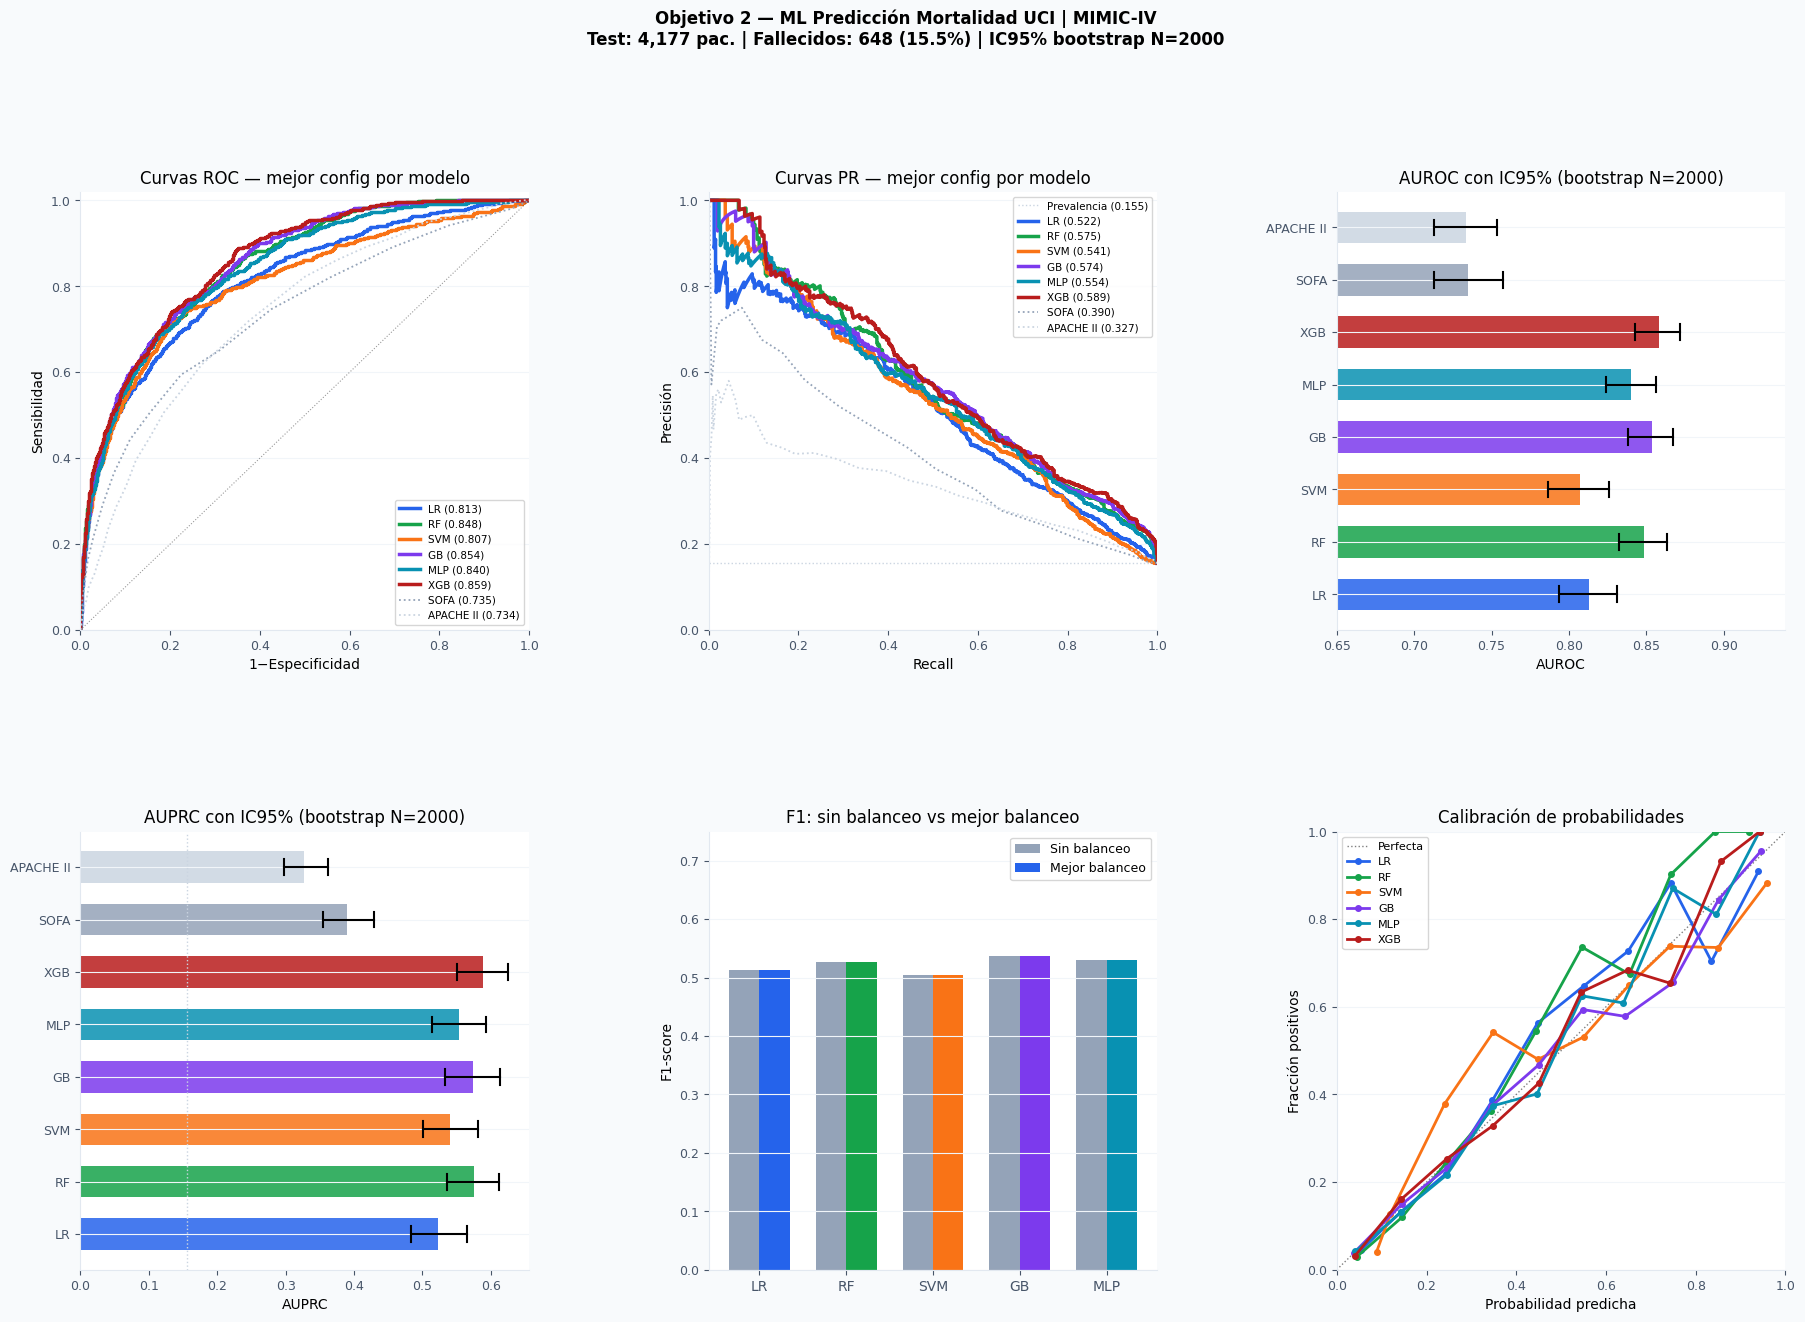

Guardado: ML_resultados_completos.png


In [45]:
def sax(ax):
    ax.set_facecolor('#FFFFFF')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#E2E8F0'); ax.spines['bottom'].set_color('#E2E8F0')
    ax.tick_params(colors='#475569', labelsize=9)
    ax.yaxis.grid(True, color='#F1F5F9', linewidth=0.8, zorder=0)

fig = plt.figure(figsize=(22, 14)); fig.patch.set_facecolor('#F8FAFC')
gs  = gridspec.GridSpec(2, 3, figure=fig, wspace=0.40, hspace=0.46)

ax1 = fig.add_subplot(gs[0,0]); sax(ax1)
for n, cfg in mejores.items():
    lw = 2.5 if n not in ['SOFA','APACHE II'] else 1.3
    ls = '-'  if n not in ['SOFA','APACHE II'] else ':'
    fpr, tpr, _ = roc_curve(y_test_arr, cfg['p_test'])
    ax1.plot(fpr, tpr, color=COLS_PLOT[n], lw=lw, ls=ls, label=f"{n} ({cfg['m']['AUROC']:.3f})")
ax1.plot([0,1],[0,1],'k:',lw=0.8,alpha=0.4)
ax1.set(xlabel='1−Especificidad', ylabel='Sensibilidad',
        title='Curvas ROC — mejor config por modelo', xlim=[0,1], ylim=[0,1.02])
ax1.legend(fontsize=7.5, loc='lower right')

ax2 = fig.add_subplot(gs[0,1]); sax(ax2)
ax2.axhline(y_test_arr.mean(), color='#CBD5E1', lw=1, ls=':', label=f'Prevalencia ({y_test_arr.mean():.3f})')
for n, cfg in mejores.items():
    lw = 2.5 if n not in ['SOFA','APACHE II'] else 1.3
    ls = '-'  if n not in ['SOFA','APACHE II'] else ':'
    prec, rec, _ = precision_recall_curve(y_test_arr, cfg['p_test'])
    ax2.plot(rec, prec, color=COLS_PLOT[n], lw=lw, ls=ls, label=f"{n} ({cfg['m']['AUPRC']:.3f})")
ax2.set(xlabel='Recall', ylabel='Precisión', title='Curvas PR — mejor config por modelo',
        xlim=[0,1], ylim=[0,1.02])
ax2.legend(fontsize=7.5, loc='upper right')

nombres_b = list(mejores.keys())
ax3 = fig.add_subplot(gs[0,2]); sax(ax3)
for i, n in enumerate(nombres_b):
    v=mejores[n]['m']['AUROC']; lo,hi=mejores[n]['ci']['AUROC']
    ax3.barh(i, v, color=COLS_PLOT[n], height=0.6, alpha=0.85)
    ax3.plot([lo,hi],[i,i],'k-',lw=1.5); ax3.plot([lo,lo],[i-.15,i+.15],'k-',lw=1.5)
    ax3.plot([hi,hi],[i-.15,i+.15],'k-',lw=1.5)
ax3.set_yticks(range(len(nombres_b))); ax3.set_yticklabels(nombres_b, fontsize=9)
ax3.set(xlabel='AUROC', title='AUROC con IC95% (bootstrap N=2000)', xlim=[0.65,0.94])

ax4 = fig.add_subplot(gs[1,0]); sax(ax4)
for i, n in enumerate(nombres_b):
    v=mejores[n]['m']['AUPRC']; lo,hi=mejores[n]['ci']['AUPRC']
    ax4.barh(i, v, color=COLS_PLOT[n], height=0.6, alpha=0.85)
    ax4.plot([lo,hi],[i,i],'k-',lw=1.5); ax4.plot([lo,lo],[i-.15,i+.15],'k-',lw=1.5)
    ax4.plot([hi,hi],[i-.15,i+.15],'k-',lw=1.5)
ax4.set_yticks(range(len(nombres_b))); ax4.set_yticklabels(nombres_b, fontsize=9)
ax4.axvline(y_test_arr.mean(), color='#CBD5E1', lw=1, ls=':')
ax4.set(xlabel='AUPRC', title='AUPRC con IC95% (bootstrap N=2000)')

ax5 = fig.add_subplot(gs[1,1]); sax(ax5)
ml_names = list(MODELOS.keys())
x5=np.arange(len(ml_names)); w5=0.35
f1_sb = [RESULTADOS[m]['sin_balanceo']['m_test']['F1'] for m in ml_names]
f1_mj = [mejores[m]['m']['F1'] for m in ml_names]
ax5.bar(x5-w5/2, f1_sb, w5, color='#94A3B8', label='Sin balanceo')
ax5.bar(x5+w5/2, f1_mj, w5, color=[COLS_PLOT[m] for m in ml_names], label='Mejor balanceo')
ax5.set_xticks(x5); ax5.set_xticklabels(ml_names, fontsize=10)
ax5.set(ylabel='F1-score', title='F1: sin balanceo vs mejor balanceo', ylim=[0,0.75])
ax5.legend(fontsize=9); ax5.xaxis.grid(False)

ax6 = fig.add_subplot(gs[1,2]); sax(ax6)
ax6.plot([0,1],[0,1],'k:',lw=1,alpha=0.5,label='Perfecta')
for n, cfg in mejores.items():
    if n in ['SOFA','APACHE II']: continue
    fp_c, mp_c = calibration_curve(y_test_arr, cfg['p_test'], n_bins=10, strategy='uniform')
    ax6.plot(mp_c, fp_c, 'o-', color=COLS_PLOT[n], lw=2, ms=4, label=n)
ax6.set(xlabel='Probabilidad predicha', ylabel='Fracción positivos',
        title='Calibración de probabilidades', xlim=[0,1], ylim=[0,1])
ax6.legend(fontsize=8)

fig.suptitle(
    'Objetivo 2 — ML Predicción Mortalidad UCI | MIMIC-IV\n'
    f'Test: {N_DEAD+N_ALIVE:,} pac. | Fallecidos: {N_DEAD} ({N_DEAD/(N_DEAD+N_ALIVE)*100:.1f}%) | IC95% bootstrap N=2000',
    fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ML_resultados_completos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: ML_resultados_completos.png')


## 12 — Guardar archivos de resultados

In [46]:
archivos = ['resultados_completos.csv','tabla_final_IC95_completa.csv','ML_resultados_completos.png']
print('Archivos generados:')
for f in archivos:
    print(f'  {"✓" if os.path.exists(f) else "✗"} {f}')

# En Colab — descarga automática:
# from google.colab import files
# for f in archivos:
#     if os.path.exists(f): files.download(f)


Archivos generados:
  ✗ resultados_completos.csv
  ✓ tabla_final_IC95_completa.csv
  ✓ ML_resultados_completos.png


---
# Parte 2 — Interpretabilidad: SHAP + LIME
**Modelo:** XGBoost (mejor configuración por AUPRC en validación)

**Contenido:**
- SHAP global: beeswarm + barplot de importancia
- SHAP local: waterfall 2×2 (TP · TN · FN · FP)
- LIME local: panel 2×2 (mismos 4 casos)
- Estabilidad LIME (10 corridas sobre Caso FN)
- Concordancia SHAP vs LIME
- SHAP vs variables SOFA / APACHE II


## 13 — Librerías e importaciones SHAP / LIME

In [47]:
import shap
import lime
import lime.lime_tabular
import xgboost as xgb_mod
from collections import Counter

UNIDADES = {
    'anchor_age': 'anos',
    'charlson': 'puntos',
    'aniongap_max': 'mEq/L',
    'bicarbonate_min': 'mEq/L',
    'lactate_max': 'mmol/L',
    'ph_min': 'pH',
    'glucose_max': 'mg/dL',
    'uo_24hr': 'mL/24h',
    'bun_max': 'mg/dL',
    'creatinine_max': 'mg/dL',
    'sbp_min': 'mmHg',
    'meanbp_min': 'mmHg',
    'inr_max': 'ratio',
    'bilirubin_max': 'mg/dL',
    'platelet_min': 'x10^3/uL',
    'pf_worst': 'mmHg',
    'heart_rate_max': 'lpm',
    'resp_rate_max': 'rpm',
    'temperature_min': 'grados C',
    'gcs_min': 'puntos',
    'wbc_max': 'x10^3/uL',
    'ventilation_24h': 'binario',
    'vasopressor_24h': 'binario',
    'gender_F': 'binario',
    'gender_M': 'binario',
}

def z_a_real(feat_name, valor_z):
    """Convierte valor z-score a escala clínica original."""
    if feat_name not in NUM_FEATURES:
        return round(float(valor_z), 3)

    fi = NUM_FEATURES.index(feat_name)
    scaler = preprocessor.named_transformers_['num']['scaler']

    return round(float(valor_z) * scaler.scale_[fi] + scaler.mean_[fi], 2)

def etiqueta_y(feat_name, valor_z):
    """Etiqueta legible: 'feature = valor unidad'."""
    vr = z_a_real(feat_name, valor_z)
    un = UNIDADES.get(feat_name, '')

    if un == 'binario':
        return feat_name + ' = ' + ('Sí' if float(vr) > 0.5 else 'No')

    return feat_name + ' = ' + str(vr) + (' ' + un if un else '')

def nombre_desde_lime(texto_lime):
    for fn in FEATURE_NAMES:
        if fn in texto_lime:
            return fn
    return texto_lime.split(' ')[0]

print('Funciones SHAP/LIME cargadas: z_a_real · etiqueta_y · nombre_desde_lime')

Funciones SHAP/LIME cargadas: z_a_real · etiqueta_y · nombre_desde_lime


## 14 — SHAP global: TreeExplainer + Beeswarm + Barplot

Calculando TreeSHAP sobre test set completo...
Base value: -1.7052 (prob=0.1538)
Prevalencia real: 0.1551

Top 10 features por |SHAP|:
        feature  mean_shap
        uo_24hr   0.386853
vasopressor_24h   0.308694
       charlson   0.296049
        bun_max   0.294669
   aniongap_max   0.197785
     anchor_age   0.170454
  bilirubin_max   0.163662
 heart_rate_max   0.157745
temperature_min   0.153997
  resp_rate_max   0.153308


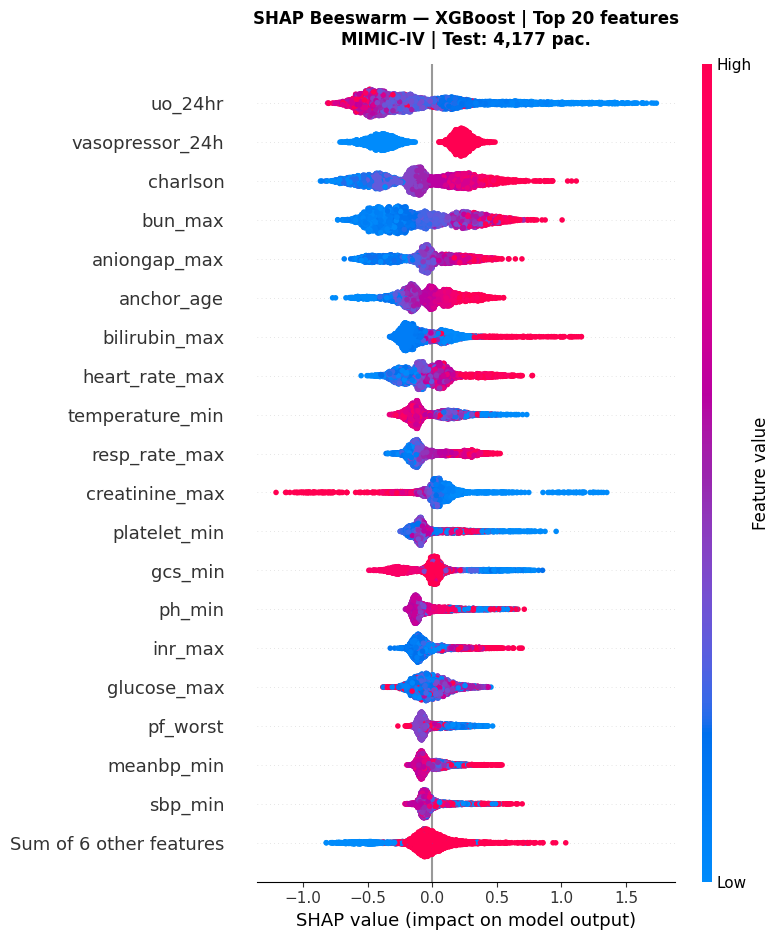

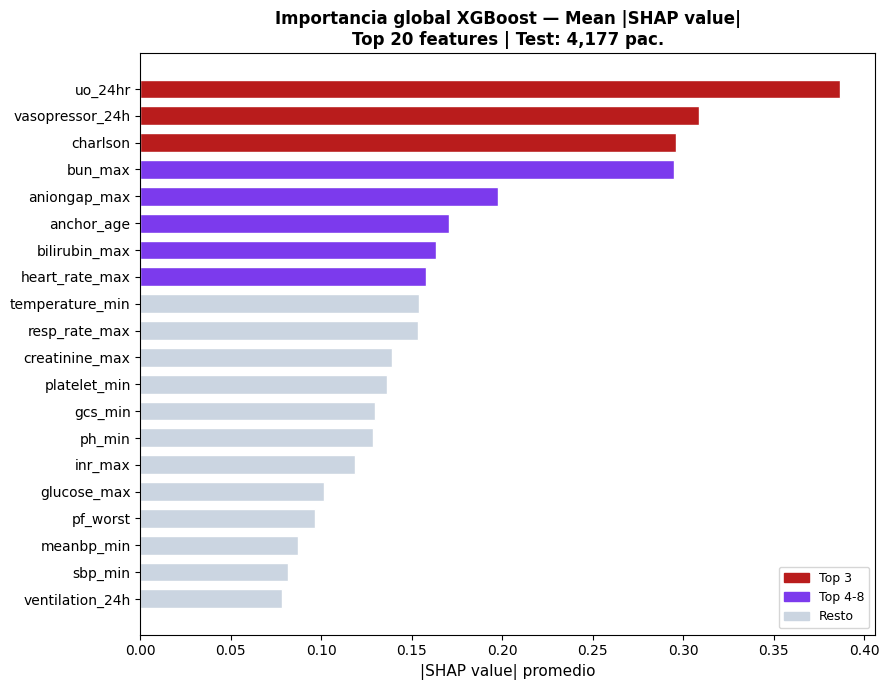

Guardados: interp_shap_beeswarm.png | interp_shap_barplot.png | shap_importancia_global.csv


In [48]:
print('Calculando TreeSHAP sobre test set completo...')
explainer   = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_test_t, check_additivity=False)

explanation = shap.Explanation(
    values        = shap_values.values,
    base_values   = explainer.expected_value,
    data          = X_test_t,
    feature_names = FEATURE_NAMES
)

base_prob = round(1 / (1 + 2.718281828**(-float(explainer.expected_value))), 4)
mean_shap  = np.abs(shap_values.values).mean(axis=0)
feat_imp   = pd.DataFrame({'feature': FEATURE_NAMES, 'mean_shap': mean_shap}
              ).sort_values('mean_shap', ascending=False).reset_index(drop=True)
feat_imp.to_csv('shap_importancia_global.csv', index=False)
print(f'Base value: {float(explainer.expected_value):.4f} (prob={base_prob})')
print(f'Prevalencia real: {y_test_arr.mean():.4f}')
print('\nTop 10 features por |SHAP|:')
print(feat_imp.head(10).to_string(index=False))

# ── Beeswarm ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(11, 9))
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title('SHAP Beeswarm — XGBoost | Top 20 features\nMIMIC-IV | Test: 4,177 pac.',
          fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('interp_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Barplot importancia ───────────────────────────────────────────────────────
from matplotlib.patches import Patch
top20  = feat_imp.head(20)
colors = ['#B91C1C' if i<3 else '#7C3AED' if i<8 else '#CBD5E1' for i in range(len(top20))]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['feature'][::-1], top20['mean_shap'][::-1],
        color=colors[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('|SHAP value| promedio', fontsize=11)
ax.set_title('Importancia global XGBoost — Mean |SHAP value|\nTop 20 features | Test: 4,177 pac.',
             fontsize=12, fontweight='bold')
ax.legend(handles=[Patch(color='#B91C1C',label='Top 3'),
                   Patch(color='#7C3AED',label='Top 4-8'),
                   Patch(color='#CBD5E1',label='Resto')], fontsize=9)
plt.tight_layout()
plt.savefig('interp_shap_barplot.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('Guardados: interp_shap_beeswarm.png | interp_shap_barplot.png | shap_importancia_global.csv')


## 15 — Selección de los 4 casos clínicos (TP · TN · FN · FP)

In [49]:
y_pred = y_pred_xgb

idx_tp_all = np.where((y_test_arr == 1) & (y_pred == 1))[0]
idx_tn_all = np.where((y_test_arr == 0) & (y_pred == 0))[0]
idx_fn_all = np.where((y_test_arr == 1) & (y_pred == 0))[0]
idx_fp_all = np.where((y_test_arr == 0) & (y_pred == 1))[0]

CASOS = {
    'TP': {'idx': idx_tp_all[np.argmax(p_test_xgb[idx_tp_all])],
           'label': 'Alto riesgo — Verdadero Positivo', 'color': '#EF4444'},
    'TN': {'idx': idx_tn_all[np.argmin(p_test_xgb[idx_tn_all])],
           'label': 'Bajo riesgo — Verdadero Negativo', 'color': '#3B82F6'},
    'FN': {'idx': idx_fn_all[np.argmax(p_test_xgb[idx_fn_all])],
           'label': 'Falso Negativo — Error crítico',   'color': '#F97316'},
    'FP': {'idx': idx_fp_all[np.argmin(p_test_xgb[idx_fp_all])],
           'label': 'Falso Positivo — Alarma falsa',   'color': '#8B5CF6'},
}

print('=' * 70)
print('  CASOS SELECCIONADOS — mismo índice para SHAP y LIME')
print('=' * 70)
for key, caso in CASOS.items():
    idx = caso['idx']; prob = p_test_xgb[idx]; real = int(y_test_arr[idx])
    ok = ((key=='TP' and prob>=t_opt_xgb and real==1) or
          (key=='TN' and prob< t_opt_xgb and real==0) or
          (key=='FN' and prob< t_opt_xgb and real==1) or
          (key=='FP' and prob>=t_opt_xgb and real==0))
    print(f'  Caso {key} [{"OK" if ok else "REVISAR"}]  idx={idx}  '
          f'P(muerte)={prob:.4f}  Umbral={t_opt_xgb}  '
          f'Pred={"MUERTO" if prob>=t_opt_xgb else "VIVO"}  '
          f'Real={"Falleció" if real==1 else "Sobrevivió"}')


  CASOS SELECCIONADOS — mismo índice para SHAP y LIME
  Caso TP [OK]  idx=322  P(muerte)=0.9803  Umbral=0.3  Pred=MUERTO  Real=Falleció
  Caso TN [OK]  idx=2721  P(muerte)=0.0020  Umbral=0.3  Pred=VIVO  Real=Sobrevivió
  Caso FN [OK]  idx=732  P(muerte)=0.2993  Umbral=0.3  Pred=VIVO  Real=Falleció
  Caso FP [OK]  idx=1915  P(muerte)=0.3001  Umbral=0.3  Pred=MUERTO  Real=Sobrevivió


## 16 — SHAP Waterfall — panel 2×2 (TP · TN · FN · FP)

In [50]:
import io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import numpy as np
import pandas as pd

TITULOS_SHAP = {
    'TP': 'SHAP — Caso 1: ALTO RIESGO (Verdadero Positivo)',
    'TN': 'SHAP — Caso 2: BAJO RIESGO (Verdadero Negativo)',
    'FN': 'SHAP — Caso 3: FALSO NEGATIVO (Error crítico)',
    'FP': 'SHAP — Caso 4: FALSO POSITIVO (Alarma falsa)',
}
MAX_DISPLAY = 12

def waterfall_a_imagen(caso_key):
    caso     = CASOS[caso_key]
    idx      = caso['idx']
    prob     = float(p_test_xgb[idx])
    real     = int(y_test_arr[idx])
    pred_str = 'MUERTO'   if prob >= t_opt_xgb else 'VIVO'
    real_str = 'Falleció' if real == 1          else 'Sobrevivió'

    # Mapa etiquetas con valores clínicos reales
    sv    = shap_values.values[idx]
    orden = np.argsort(np.abs(sv))[::-1][:MAX_DISPLAY]
    etiq_map = {
        FEATURE_NAMES[i]: etiqueta_y(FEATURE_NAMES[i], float(shap_values.data[idx][i]))
        for i in orden
    }

    # ── SHAP genera su propia figura internamente ─────────────────────
    shap.plots.waterfall(explanation[idx], max_display=MAX_DISPLAY, show=False)
    fig_shap = plt.gcf()
    fig_shap.set_size_inches(13, 10)
    fig_shap.patch.set_facecolor('#FFFFFF')
    ax_shap = fig_shap.axes[0]
    ax_shap.set_facecolor('#FFFFFF')

    # ── Reemplazar etiquetas eje Y con valores clínicos ───────────────
    nuevas = []
    for tick in ax_shap.get_yticklabels():
        texto  = tick.get_text().strip()
        fn_enc = next((fn for fn in FEATURE_NAMES if texto.startswith(fn)), None)
        nuevas.append(etiq_map.get(fn_enc, texto) if fn_enc else texto)
    if nuevas:
        ax_shap.set_yticklabels(nuevas, fontsize=11)

    # ── Eje X ─────────────────────────────────────────────────────────
    ax_shap.tick_params(axis='x', labelsize=10)
    ax_shap.set_xlabel(ax_shap.get_xlabel(), fontsize=11)

    # ── Estilo consistente con LIME ───────────────────────────────────
    for sp in ['top', 'right']:
        ax_shap.spines[sp].set_visible(False)
    ax_shap.spines['left'].set_color('#E2E8F0')
    ax_shap.spines['bottom'].set_color('#E2E8F0')
    ax_shap.grid(axis='x', alpha=0.25, linestyle=':')

    # ── Título de cada caso ───────────────────────────────────────────
    titulo = (
        TITULOS_SHAP[caso_key] + '\n'
        f'P(muerte)={prob:.3f}  |  Umbral={t_opt_xgb}'
        f'  |  Pred: {pred_str}  |  Real: {real_str}'
    )
    ax_shap.set_title(
        titulo,
        fontsize   = 12,
        fontweight = 'bold',
        color      = caso['color'],
        pad        = 12
    )

    fig_shap.tight_layout()

    # ── Guardar PNG individual ────────────────────────────────────────
    fig_shap.savefig(
        f'interp_waterfall_{caso_key}.png',
        dpi=150, bbox_inches='tight', facecolor='white'
    )

    # ── Capturar en buffer para el panel 2×2 ─────────────────────────
    buf = io.BytesIO()
    fig_shap.savefig(
        buf, format='png',
        dpi=150,                   # ← NO subir más de 150, genera borrosidad en el panel
        bbox_inches='tight',
        facecolor='white'
    )
    buf.seek(0)
    plt.close(fig_shap)
    return buf


# ════════════════════════════════════════════════════════════════════
# PANEL 2×2
# ════════════════════════════════════════════════════════════════════
print('Generando SHAP Waterfall 2×2...')

fig_panel = plt.figure(figsize=(26, 24))
fig_panel.patch.set_facecolor('#FAFAFA')

gs_p = gridspec.GridSpec(
    2, 2,
    figure  = fig_panel,
    hspace  = 0.15,              # ← espacio vertical entre filas
    wspace  = 0.08,              # ← espacio horizontal entre columnas
    left    = 0.02,
    right   = 0.98,
    top     = 0.88,              # ← CLAVE: deja espacio arriba para el título
    bottom  = 0.02
)

for pos, key in enumerate(['TP', 'TN', 'FN', 'FP']):
    buf = waterfall_a_imagen(key)
    row, col = divmod(pos, 2)
    ax = fig_panel.add_subplot(gs_p[row, col])
    img = plt.imread(buf)
    ax.imshow(img, aspect='auto', interpolation='lanczos')
    ax.axis('off')

# ── Título general ────────────────────────────────────────────────────────────
fig_panel.suptitle(
    'SHAP Waterfall — 4 casos clínicos | XGBoost | MIMIC-IV\n'
    'Rojo = aumenta P(muerte)  |  Azul = reduce P(muerte)',
    fontsize   = 15,
    fontweight = 'bold',
    color      = '#1E3A5F',
    y          = 0.97            # ← queda en el espacio libre sobre top=0.88
)

plt.savefig(
    'interp_shap_waterfall_2x2.png',
    dpi         = 180,
    bbox_inches = 'tight',
    facecolor   = '#FAFAFA'
)
plt.show()
plt.close()

# ════════════════════════════════════════════════════════════════════
# CSV POR CASO
# ════════════════════════════════════════════════════════════════════
for key in ['TP', 'TN', 'FN', 'FP']:
    caso  = CASOS[key]
    idx   = caso['idx']
    sv    = shap_values.values[idx]
    orden = np.argsort(np.abs(sv))[::-1][:MAX_DISPLAY]
    pd.DataFrame([{
        'Feature'   : FEATURE_NAMES[i],
        'Valor_real': z_a_real(FEATURE_NAMES[i], float(shap_values.data[idx][i])),
        'Unidad'    : UNIDADES.get(FEATURE_NAMES[i], ''),
        'SHAP'      : round(float(sv[i]), 4),
        'Direccion' : '+riesgo' if sv[i] > 0 else '-riesgo',
    } for i in orden]).to_csv(f'shap_caso_{key}.csv', index=False)

print('Guardados: interp_shap_waterfall_2x2.png  |  4 PNG individuales  |  4 CSV')

Generando SHAP Waterfall 2×2...


<Figure size 640x480 with 0 Axes>

Guardados: interp_shap_waterfall_2x2.png  |  4 PNG individuales  |  4 CSV


## 17 — LIME — panel 2×2 (TP · TN · FN · FP)

Calculando LIME para los 4 casos...
  TP: P(LIME)=0.9803  P(XGB)=0.9803
  TN: P(LIME)=0.0020  P(XGB)=0.0020
  FN: P(LIME)=0.2993  P(XGB)=0.2993
  FP: P(LIME)=0.3001  P(XGB)=0.3001


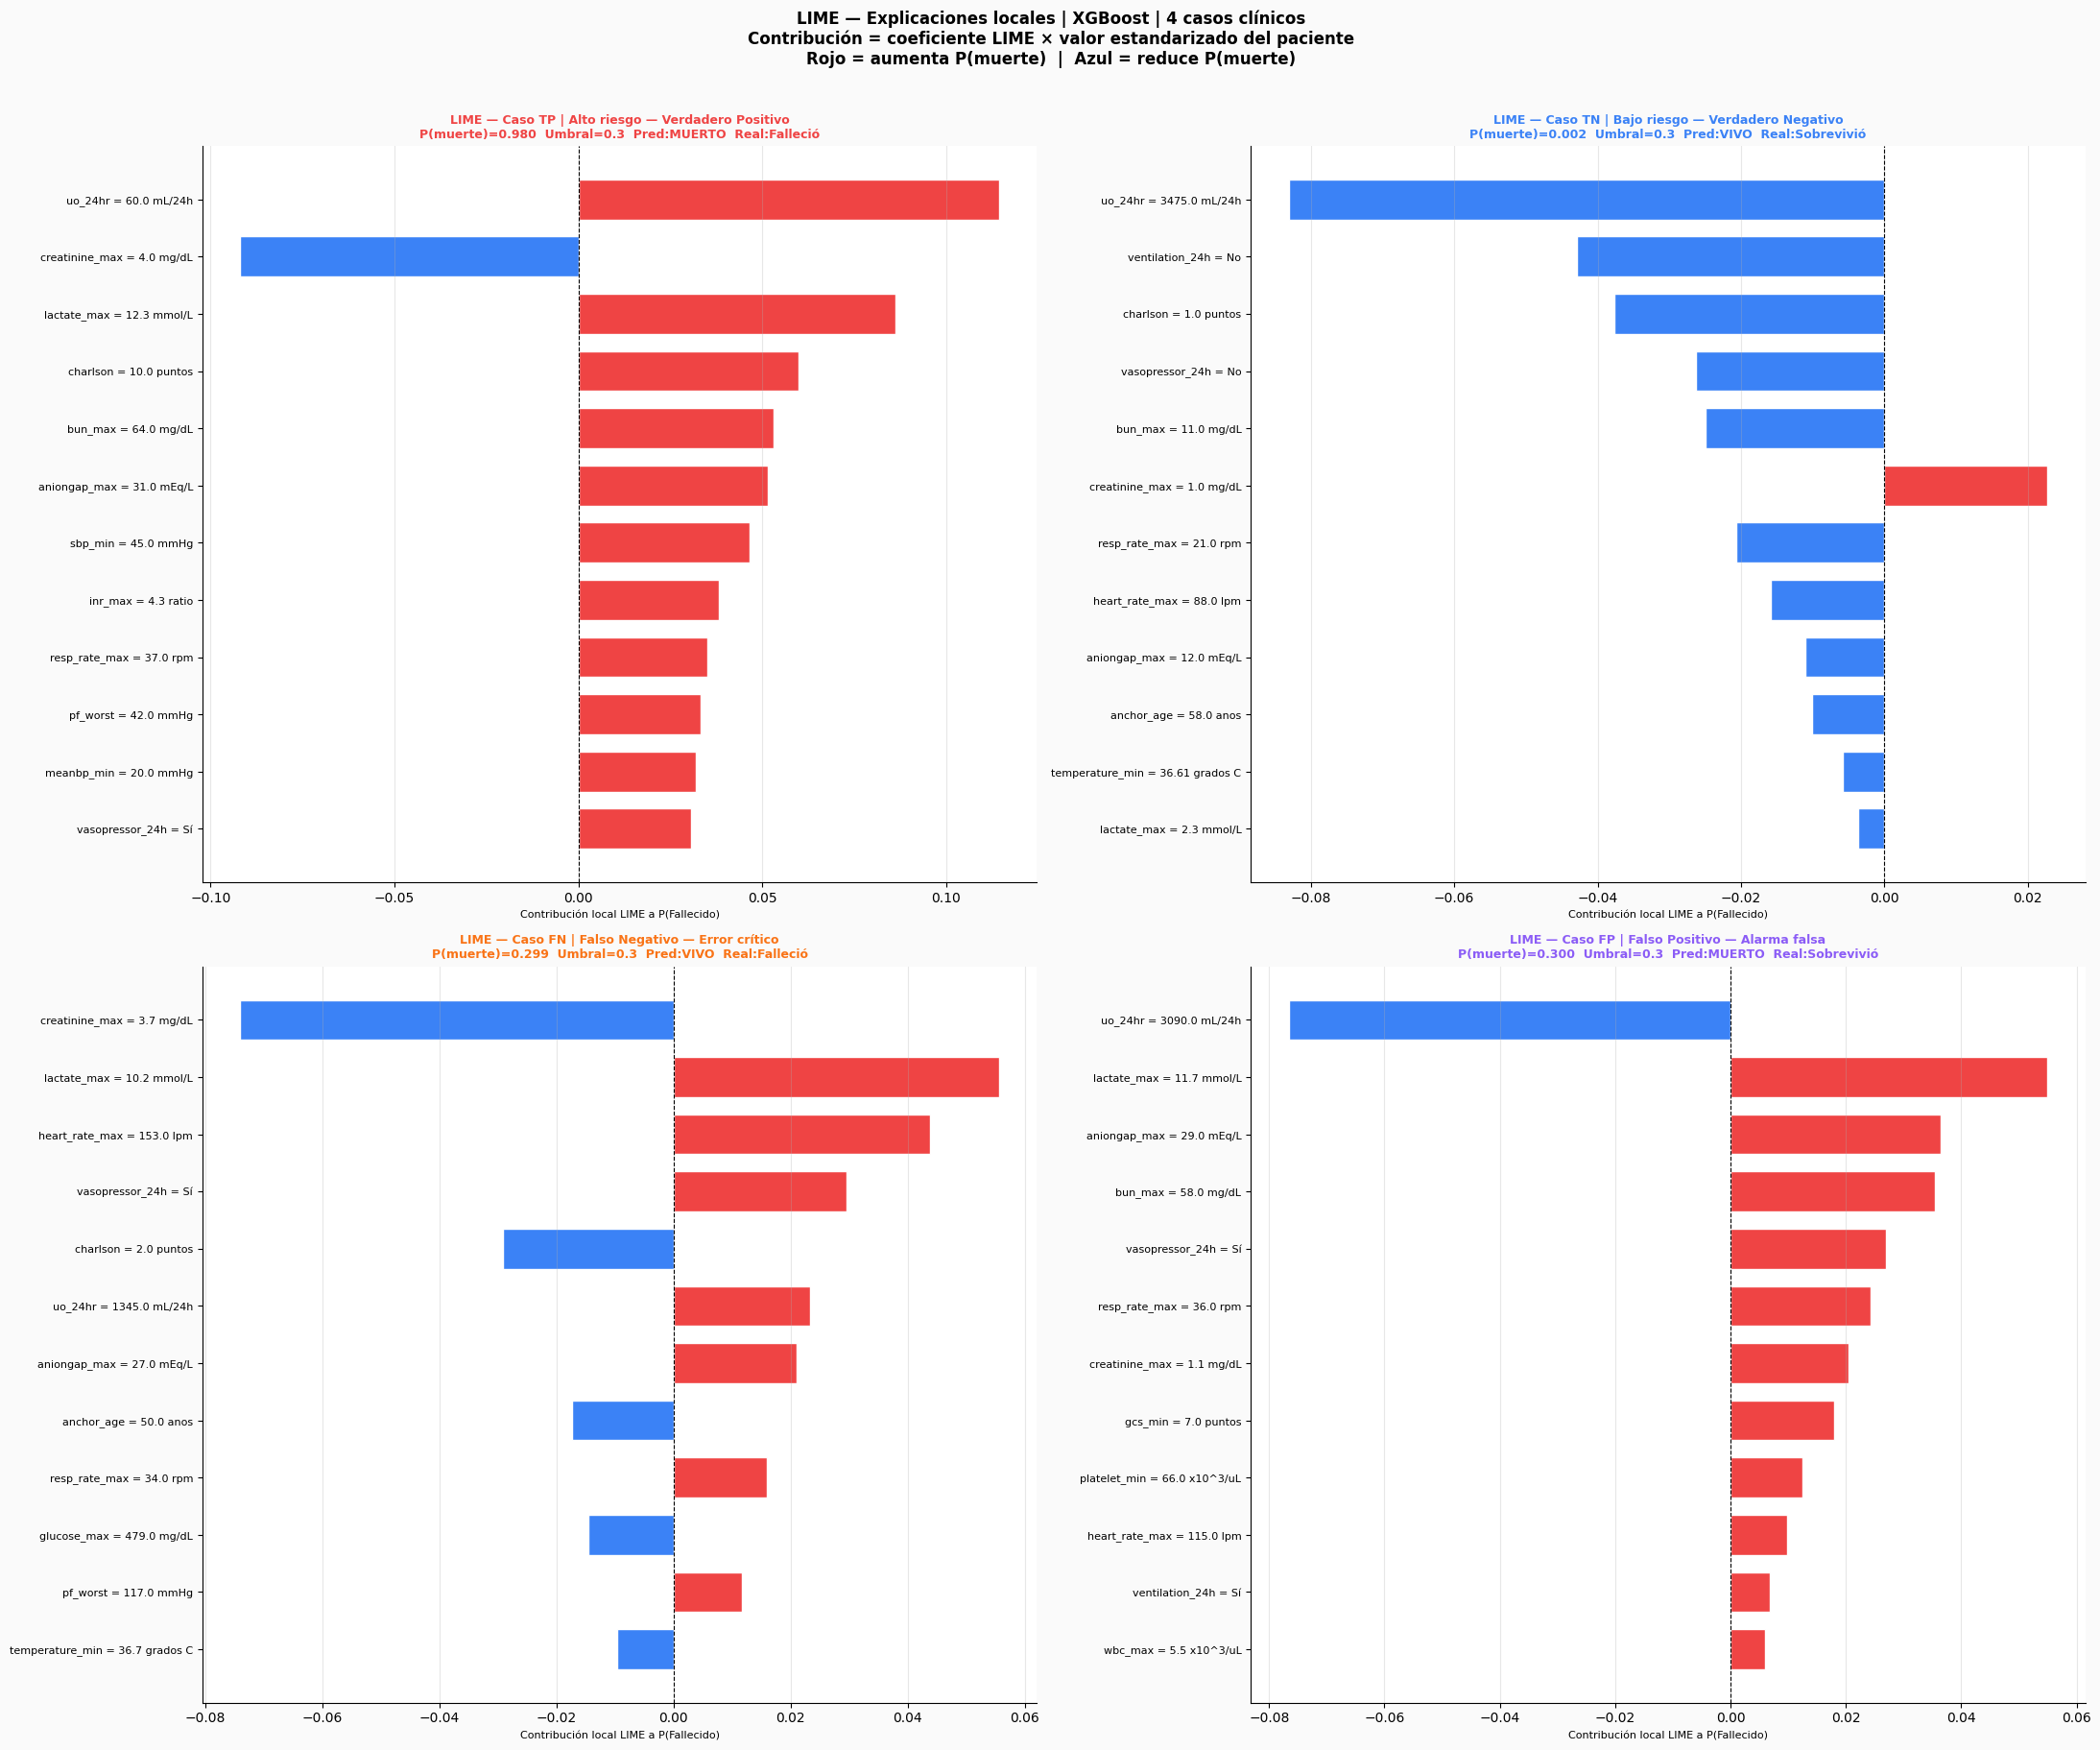

Guardado: interp_lime_4casos.png


In [51]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train_t,
    feature_names         = FEATURE_NAMES,
    class_names           = ['Sobrevive', 'Muere'],
    mode                  = 'classification',
    discretize_continuous = False,
    random_state          = SEED
)

def xgb_predict_lime(instances):
    dmat = xgb_mod.DMatrix(instances, feature_names=FEATURE_NAMES)
    n    = modelo_xgb.best_iteration + 1
    p    = modelo_xgb.predict(dmat, iteration_range=(0, n))
    return np.column_stack([1-p, p])

LIME_N_FEAT, LIME_N_SAMPLES = 15, 5000

print('Calculando LIME para los 4 casos...')
lime_xgb = {}
for key, caso in CASOS.items():
    exp = lime_explainer.explain_instance(
        data_row   = X_test_t[caso['idx']],
        predict_fn = xgb_predict_lime,
        num_features = LIME_N_FEAT,
        num_samples  = LIME_N_SAMPLES,
        labels=(1,)
    )
    lime_xgb[key] = exp
    print(f'  {key}: P(LIME)={exp.predict_proba[1]:.4f}  P(XGB)={p_test_xgb[caso["idx"]]:.4f}')

# ── Panel 2×2 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 18)); fig.patch.set_facecolor('#FAFAFA')

for ax, (key, caso) in zip(axes.flatten(), CASOS.items()):
    exp      = lime_xgb[key]; idx = caso['idx']
    prob_xgb = float(p_test_xgb[idx]); real = int(y_test_arr[idx])
    pred_str = 'MUERTO'   if prob_xgb >= t_opt_xgb else 'VIVO'
    real_str = 'Falleció' if real == 1               else 'Sobrevivió'

    # Contribución real = coef × valor_z (refleja efecto clínico del valor del paciente)
    items = sorted([
        (FEATURE_NAMES[fi], fi, coef, float(X_test_t[idx, fi]), coef * float(X_test_t[idx, fi]))
        for fi, coef in exp.local_exp[1]
    ], key=lambda x: abs(x[4]), reverse=True)[:12]

    etqs = [etiqueta_y(fn, vz) for fn,_,_,vz,_ in items][::-1]
    peso = [c for _,_,_,_,c in items][::-1]
    cols = ['#EF4444' if p>0 else '#3B82F6' for p in peso]

    ax.barh(etqs, peso, color=cols, edgecolor='white', height=0.7)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(
        f'LIME — Caso {key} | {caso["label"]}\n'
        f'P(muerte)={prob_xgb:.3f}  Umbral={t_opt_xgb}  Pred:{pred_str}  Real:{real_str}',
        fontsize=9, fontweight='bold', color=caso['color'])
    ax.set_xlabel('Contribución local LIME a P(Fallecido)', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.suptitle(
    'LIME — Explicaciones locales | XGBoost | 4 casos clínicos\n'
    'Contribución = coeficiente LIME × valor estandarizado del paciente\n'
    'Rojo = aumenta P(muerte)  |  Azul = reduce P(muerte)',
    fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('interp_lime_4casos.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('Guardado: interp_lime_4casos.png')


## 18 — Estabilidad LIME (10 corridas sobre Caso FN)

Ejecutando LIME 10 veces sobre Caso FN (semillas distintas)...
  Run 01: ['uo_24hr', 'creatinine_max', 'charlson', 'vasopressor_24h', 'anchor_age']
  Run 02: ['uo_24hr', 'creatinine_max', 'vasopressor_24h', 'charlson', 'resp_rate_max']
  Run 03: ['uo_24hr', 'creatinine_max', 'vasopressor_24h', 'charlson', 'resp_rate_max']
  Run 04: ['uo_24hr', 'creatinine_max', 'charlson', 'vasopressor_24h', 'heart_rate_max']
  Run 05: ['uo_24hr', 'creatinine_max', 'vasopressor_24h', 'charlson', 'anchor_age']
  Run 06: ['uo_24hr', 'creatinine_max', 'vasopressor_24h', 'charlson', 'resp_rate_max']
  Run 07: ['uo_24hr', 'creatinine_max', 'charlson', 'vasopressor_24h', 'heart_rate_max']
  Run 08: ['uo_24hr', 'creatinine_max', 'vasopressor_24h', 'charlson', 'resp_rate_max']
  Run 09: ['uo_24hr', 'creatinine_max', 'vasopressor_24h', 'charlson', 'ventilation_24h']
  Run 10: ['uo_24hr', 'creatinine_max', 'charlson', 'anchor_age', 'vasopressor_24h']

Estabilidad LIME:
        Feature  Apariciones_10  Peso_prome

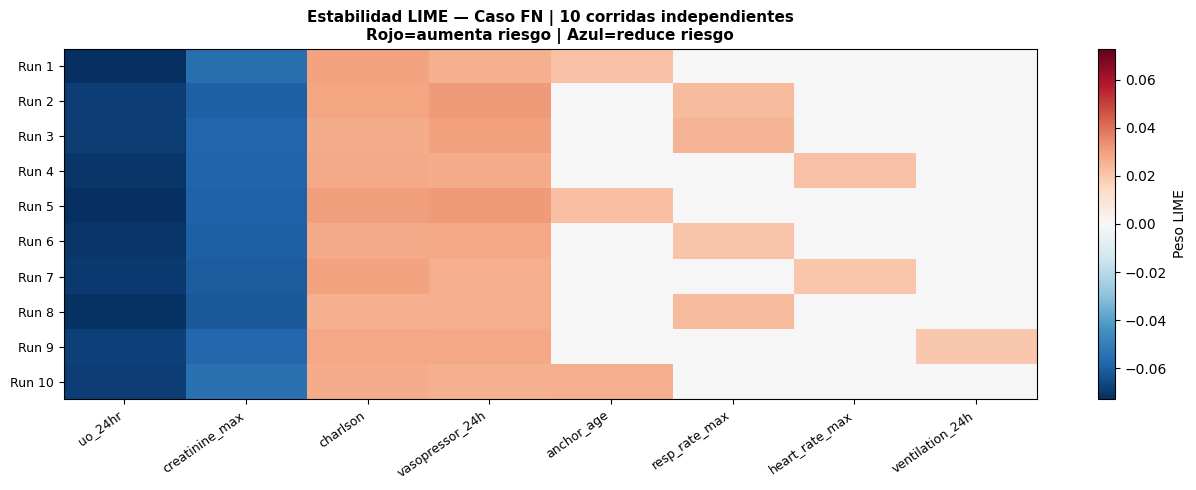

Guardados: lime_estabilidad_FN.csv | interp_lime_estabilidad.png


In [52]:
idx_fn = CASOS['FN']['idx']
N_RUNS, TOP_K = 10, 5

print(f'Ejecutando LIME {N_RUNS} veces sobre Caso FN (semillas distintas)...')
runs = []
for run in range(N_RUNS):
    np.random.seed(run * 7); random.seed(run * 7)
    exp = lime_explainer.explain_instance(
        data_row=X_test_t[idx_fn], predict_fn=xgb_predict_lime,
        num_features=LIME_N_FEAT, num_samples=LIME_N_SAMPLES, labels=(1,))
    top5 = [(f[0][:30], round(f[1],4)) for f in exp.as_list(label=1)[:TOP_K]]
    runs.append(top5)
    print(f'  Run {run+1:02d}: {[f[0] for f in top5]}')

feat_counts, feat_weights = Counter(), {}
for run in runs:
    for fname, fw in run:
        feat_counts[fname] += 1
        feat_weights.setdefault(fname,[]).append(fw)

df_stab = pd.DataFrame([{
    'Feature': f, 'Apariciones_10': cnt,
    'Peso_promedio': round(np.mean(feat_weights[f]),4),
    'Peso_std': round(np.std(feat_weights[f]),4),
    'Estable_7de10': 'SI' if cnt>=7 else 'NO',
} for f,cnt in feat_counts.most_common()])
df_stab.to_csv('lime_estabilidad_FN.csv', index=False)
print('\nEstabilidad LIME:')
print(df_stab.to_string(index=False))
n_est = int((df_stab['Estable_7de10']=='SI').sum())
print(f'\n{n_est} features estables (≥7/10) → {"ESTABLE" if n_est>=3 else "INESTABLE"}')

# Heatmap
all_f = list(feat_counts.keys())[:12]
mat   = np.zeros((N_RUNS, len(all_f)))
for i, run in enumerate(runs):
    for fname, fw in run:
        if fname in all_f: mat[i, all_f.index(fname)] = fw

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto',
               vmin=-np.abs(mat).max(), vmax=np.abs(mat).max())
ax.set_xticks(range(len(all_f))); ax.set_xticklabels(all_f, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(N_RUNS));    ax.set_yticklabels([f'Run {i+1}' for i in range(N_RUNS)], fontsize=9)
plt.colorbar(im, ax=ax, label='Peso LIME')
ax.set_title('Estabilidad LIME — Caso FN | 10 corridas independientes\n'
             'Rojo=aumenta riesgo | Azul=reduce riesgo', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('interp_lime_estabilidad.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print('Guardados: lime_estabilidad_FN.csv | interp_lime_estabilidad.png')


## 19 — Concordancia SHAP vs LIME (Top 5 variables)

In [53]:
TOP_CONCORD = 5
concord_rows = []

print('=' * 70)
print(f'  CONCORDANCIA SHAP vs LIME — TOP {TOP_CONCORD} variables por caso')
print('=' * 70)

for key, caso in CASOS.items():
    idx  = caso['idx']
    sv   = shap_values.values[idx]
    top_shap = set(FEATURE_NAMES[i] for i in np.argsort(np.abs(sv))[::-1][:TOP_CONCORD])
    top_lime = set()
    for texto, _ in lime_xgb[key].as_list(label=1)[:TOP_CONCORD]:
        fn = nombre_desde_lime(texto)
        if fn in FEATURE_NAMES: top_lime.add(fn)

    coinciden = top_shap & top_lime
    n_match   = len(coinciden)
    robustez  = 'Alta' if n_match>=4 else ('Media' if n_match>=3 else 'Baja')

    concord_rows.append({
        'Caso': key, 'Label': caso['label'],
        'P_muerte': round(float(p_test_xgb[idx]),4),
        'Real': 'Falleció' if y_test_arr[idx]==1 else 'Sobrevivió',
        'Coincidencias_de_5': n_match, 'Robustez': robustez,
        'Coincidentes': ', '.join(sorted(coinciden)),
        'Solo_SHAP': ', '.join(sorted(top_shap-top_lime)),
        'Solo_LIME': ', '.join(sorted(top_lime-top_shap)),
    })
    print(f'\n  Caso {key} — {caso["label"]}')
    print(f'  Coincidencias: {n_match}/5 — {robustez}')
    print(f'  SHAP: {sorted(top_shap)}')
    print(f'  LIME: {sorted(top_lime)}')
    print(f'  Coinciden: {sorted(coinciden)}')

df_concord = pd.DataFrame(concord_rows)
df_concord.to_csv('concordancia_shap_lime.csv', index=False)
print('\nGuardado: concordancia_shap_lime.csv')
print(df_concord[['Caso','Coincidencias_de_5','Robustez','Coincidentes']].to_string(index=False))


  CONCORDANCIA SHAP vs LIME — TOP 5 variables por caso

  Caso TP — Alto riesgo — Verdadero Positivo
  Coincidencias: 1/5 — Baja
  SHAP: ['anchor_age', 'aniongap_max', 'lactate_max', 'ph_min', 'uo_24hr']
  LIME: ['bun_max', 'charlson', 'creatinine_max', 'uo_24hr', 'vasopressor_24h']
  Coinciden: ['uo_24hr']

  Caso TN — Bajo riesgo — Verdadero Negativo
  Coincidencias: 4/5 — Alta
  SHAP: ['bun_max', 'charlson', 'uo_24hr', 'vasopressor_24h', 'ventilation_24h']
  LIME: ['bun_max', 'charlson', 'creatinine_max', 'uo_24hr', 'vasopressor_24h']
  Coinciden: ['bun_max', 'charlson', 'uo_24hr', 'vasopressor_24h']

  Caso FN — Falso Negativo — Error crítico
  Coincidencias: 2/5 — Baja
  SHAP: ['aniongap_max', 'charlson', 'lactate_max', 'ph_min', 'vasopressor_24h']
  LIME: ['charlson', 'creatinine_max', 'uo_24hr', 'vasopressor_24h', 'ventilation_24h']
  Coinciden: ['charlson', 'vasopressor_24h']

  Caso FP — Falso Positivo — Alarma falsa
  Coincidencias: 3/5 — Media
  SHAP: ['aniongap_max', 'bun_m

## 20 — SHAP vs variables SOFA / APACHE II

In [54]:
SOFA_VARS   = ['pf_worst','platelet_min','bilirubin_max','meanbp_min',
               'vasopressor_24h','gcs_min','creatinine_max','uo_24hr']
APACHE_VARS = ['temperature_min','meanbp_min','heart_rate_max','resp_rate_max',
               'ph_min','creatinine_max','platelet_min','gcs_min','wbc_max','anchor_age']

scores_vars = set(SOFA_VARS + APACHE_VARS)
feat_comp   = feat_imp.copy()
feat_comp['Rank_SHAP'] = range(1, len(feat_comp)+1)
feat_comp['En_SOFA']   = feat_comp['feature'].isin(SOFA_VARS).map({True:'SI',False:'NO'})
feat_comp['En_APACHE'] = feat_comp['feature'].isin(APACHE_VARS).map({True:'SI',False:'NO'})
feat_comp['Solo_ML']   = (~feat_comp['feature'].isin(scores_vars)).map({True:'SI',False:'NO'})

print('Ranking SHAP vs presencia en SOFA / APACHE II (top 20):')
print(feat_comp[['Rank_SHAP','feature','mean_shap','En_SOFA','En_APACHE','Solo_ML']
                ].head(20).to_string(index=False))

solo_ml = feat_comp[feat_comp['Solo_ML']=='SI'].reset_index(drop=True)
print('\nVariables Solo_ML (no en SOFA ni APACHE II):')
print(solo_ml[['Rank_SHAP','feature','mean_shap']].to_string(index=False))

feat_comp.to_csv('shap_vs_scores_clinicos.csv', index=False)
solo_ml.to_csv('variables_sorpresa_ml.csv', index=False)
print('\nGuardados: shap_vs_scores_clinicos.csv | variables_sorpresa_ml.csv')


Ranking SHAP vs presencia en SOFA / APACHE II (top 20):
 Rank_SHAP         feature  mean_shap En_SOFA En_APACHE Solo_ML
         1         uo_24hr   0.386853      SI        NO      NO
         2 vasopressor_24h   0.308694      SI        NO      NO
         3        charlson   0.296049      NO        NO      SI
         4         bun_max   0.294669      NO        NO      SI
         5    aniongap_max   0.197785      NO        NO      SI
         6      anchor_age   0.170454      NO        SI      NO
         7   bilirubin_max   0.163662      SI        NO      NO
         8  heart_rate_max   0.157745      NO        SI      NO
         9 temperature_min   0.153997      NO        SI      NO
        10   resp_rate_max   0.153308      NO        SI      NO
        11  creatinine_max   0.139115      SI        SI      NO
        12    platelet_min   0.136248      SI        SI      NO
        13         gcs_min   0.129548      SI        SI      NO
        14          ph_min   0.128633      NO   

## 21 — Resumen de archivos generados

In [55]:
archivos_todos = [
    # Resultados ML
    'resultados_completos.csv',
    'tabla_final_IC95_completa.csv',
    'ML_resultados_completos.png',
    # SHAP global
    'shap_importancia_global.csv',
    'interp_shap_beeswarm.png',
    'interp_shap_barplot.png',
    # SHAP casos
    'interp_shap_waterfall_2x2.png',
    'interp_waterfall_TP.png',
    'interp_waterfall_TN.png',
    'interp_waterfall_FN.png',
    'interp_waterfall_FP.png',
    'shap_caso_TP.csv','shap_caso_TN.csv','shap_caso_FN.csv','shap_caso_FP.csv',
    # LIME
    'interp_lime_4casos.png',
    'interp_lime_estabilidad.png',
    'lime_estabilidad_FN.csv',
    # Concordancia
    'concordancia_shap_lime.csv',
    # SHAP vs scores
    'shap_vs_scores_clinicos.csv',
    'variables_sorpresa_ml.csv',
]

print('Archivos generados:')
ok, missing = 0, 0
for f in archivos_todos:
    existe = os.path.exists(f)
    print(f'  {"✓" if existe else "✗"} {f}')
    if existe: ok+=1
    else: missing+=1
print(f'\nTotal: {ok} generados / {missing} faltantes')

# En Colab — descarga automática (descomenta):
# from google.colab import files
# for f in archivos_todos:
#     if os.path.exists(f): files.download(f)


Archivos generados:
  ✗ resultados_completos.csv
  ✓ tabla_final_IC95_completa.csv
  ✓ ML_resultados_completos.png
  ✓ shap_importancia_global.csv
  ✓ interp_shap_beeswarm.png
  ✓ interp_shap_barplot.png
  ✓ interp_shap_waterfall_2x2.png
  ✓ interp_waterfall_TP.png
  ✓ interp_waterfall_TN.png
  ✓ interp_waterfall_FN.png
  ✓ interp_waterfall_FP.png
  ✓ shap_caso_TP.csv
  ✓ shap_caso_TN.csv
  ✓ shap_caso_FN.csv
  ✓ shap_caso_FP.csv
  ✓ interp_lime_4casos.png
  ✓ interp_lime_estabilidad.png
  ✓ lime_estabilidad_FN.csv
  ✓ concordancia_shap_lime.csv
  ✓ shap_vs_scores_clinicos.csv
  ✓ variables_sorpresa_ml.csv

Total: 20 generados / 1 faltantes
